# Task 1

In [3]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
!unzip /content/kmeans_data.zip
!rm -rf /content/__MACOSX

Archive:  /content/kmeans_data.zip
replace data_description.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
X = pd.read_csv('data.csv', header=None).values.astype(float)
y = pd.read_csv('label.csv', header=None).values.flatten()
K = len(np.unique(y))

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def cosine_distance(a, b):
    dot = np.dot(a, b)
    na = np.sqrt(np.sum(a ** 2))
    nb = np.sqrt(np.sum(b ** 2))
    if na == 0 or nb == 0:
        return 1.0
    return 1 - (dot / (na * nb))

# generalized jaccard - ref: https://www.itl.nist.gov/div898/software/dataplot/refman2/auxillar/jaccard.htm
def jaccard_distance(a, b):
    num = np.sum(np.minimum(a, b))
    den = np.sum(np.maximum(a, b))
    if den == 0:
        return 0.0
    return 1 - (num / den)

In [ ]:
def calc_sse(X, labels, centroids):
    sse = 0.0
    for i in range(len(X)):
        diff = X[i] - centroids[labels[i]]
        sse += np.sum(diff ** 2)
    return sse

In [ ]:
def run_kmeans(X, K, dist_fn, max_iter=500, seed=42):
    np.random.seed(seed)
    n = X.shape[0]
    idx = np.random.choice(n, K, replace=False)
    centroids = X[idx].copy().astype(float)
    labels = np.zeros(n, dtype=int)
    sse_history = []

    for it in range(max_iter):
        new_labels = np.zeros(n, dtype=int)
        for i in range(n):
            dists = [dist_fn(X[i], centroids[k]) for k in range(K)]
            new_labels[i] = np.argmin(dists)

        sse = calc_sse(X, new_labels, centroids)
        sse_history.append(sse)

        if it > 0 and sse > sse_history[-2]:
            labels = new_labels
            break

        if it > 0 and np.array_equal(new_labels, labels):
            labels = new_labels
            break

        labels = new_labels

        for k in range(K):
            pts = X[labels == k]
            if len(pts) > 0:
                centroids[k] = np.mean(pts, axis=0)

    return labels, centroids, sse_history[-1]

In [ ]:
def get_accuracy(true_y, pred_labels, K):
    mapping = {}
    for k in range(K):
        pts = true_y[pred_labels == k]
        if len(pts) == 0:
            mapping[k] = -1
        else:
            mapping[k] = Counter(pts).most_common(1)[0][0]
    predicted = np.array([mapping[p] for p in pred_labels])
    return np.sum(predicted == true_y) / len(true_y)

## Q1

In [ ]:
euc_labels, euc_centroids, euc_sse = run_kmeans(X, K, euclidean_distance)
cos_labels, cos_centroids, cos_sse = run_kmeans(X, K, cosine_distance)
jac_labels, jac_centroids, jac_sse = run_kmeans(X, K, jaccard_distance)

In [ ]:
print(f"Euclidean SSE : {euc_sse:.4f}")
print(f"Cosine SSE    : {cos_sse:.4f}")
print(f"Jaccard SSE   : {jac_sse:.4f}")

Euclidean SSE : 25414767689.9611
Cosine SSE    : 25489044045.3560
Jaccard SSE   : 25415242340.2997


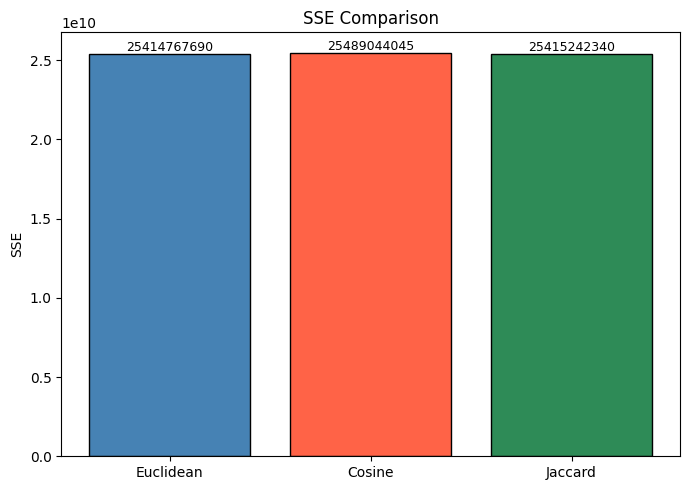

In [ ]:
names = ['Euclidean', 'Cosine', 'Jaccard']
sses = [euc_sse, cos_sse, jac_sse]
colors = ['steelblue', 'tomato', 'seagreen']

plt.figure(figsize=(7, 5))
bars = plt.bar(names, sses, color=colors, edgecolor='black')
plt.title("SSE Comparison")
plt.ylabel("SSE")
for bar, val in zip(bars, sses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.0f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('q1_sse.png', dpi=150)
plt.show()

## Q2

In [ ]:
euc_acc = get_accuracy(y, euc_labels, K)
cos_acc = get_accuracy(y, cos_labels, K)
jac_acc = get_accuracy(y, jac_labels, K)

In [ ]:
print(f"Euclidean Accuracy : {euc_acc:.4f}")
print(f"Cosine Accuracy    : {cos_acc:.4f}")
print(f"Jaccard Accuracy   : {jac_acc:.4f}")

Euclidean Accuracy : 0.5851
Cosine Accuracy    : 0.6305
Jaccard Accuracy   : 0.6029


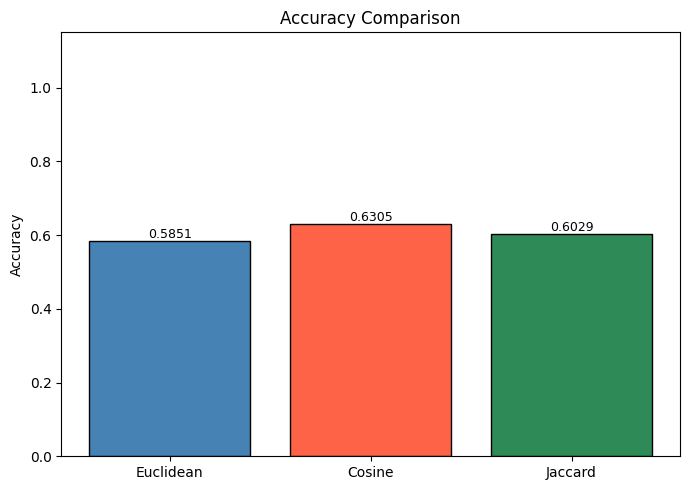

In [ ]:
accs = [euc_acc, cos_acc, jac_acc]

plt.figure(figsize=(7, 5))
bars = plt.bar(names, accs, color=colors, edgecolor='black')
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.15)
for bar, val in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.4f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('q2_accuracy.png', dpi=150)
plt.show()

## Q3

In [ ]:
def run_kmeans_timed(X, K, dist_fn, max_iter=500, seed=42):
    np.random.seed(seed)
    n = X.shape[0]
    idx = np.random.choice(n, K, replace=False)
    centroids = X[idx].copy().astype(float)
    labels = np.zeros(n, dtype=int)
    sse_history = []

    for it in range(max_iter):
        new_labels = np.zeros(n, dtype=int)
        for i in range(n):
            dists = [dist_fn(X[i], centroids[k]) for k in range(K)]
            new_labels[i] = np.argmin(dists)

        sse = calc_sse(X, new_labels, centroids)
        sse_history.append(sse)

        if it > 0 and sse > sse_history[-2]:
            labels = new_labels
            break

        if it > 0 and np.array_equal(new_labels, labels):
            labels = new_labels
            break

        labels = new_labels

        for k in range(K):
            pts = X[labels == k]
            if len(pts) > 0:
                centroids[k] = np.mean(pts, axis=0)

    return labels, len(sse_history)

In [ ]:
t0 = time.time()
_, euc_iters = run_kmeans_timed(X, K, euclidean_distance)
euc_time = time.time() - t0

t0 = time.time()
_, cos_iters = run_kmeans_timed(X, K, cosine_distance)
cos_time = time.time() - t0

t0 = time.time()
_, jac_iters = run_kmeans_timed(X, K, jaccard_distance)
jac_time = time.time() - t0

In [ ]:
print(f"Euclidean: {euc_iters} iterations, {euc_time:.2f}s")
print(f"Cosine:    {cos_iters} iterations, {cos_time:.2f}s")
print(f"Jaccard:   {jac_iters} iterations, {jac_time:.2f}s")

Euclidean: 33 iterations, 42.29s
Cosine:    34 iterations, 75.48s
Jaccard:   38 iterations, 63.14s


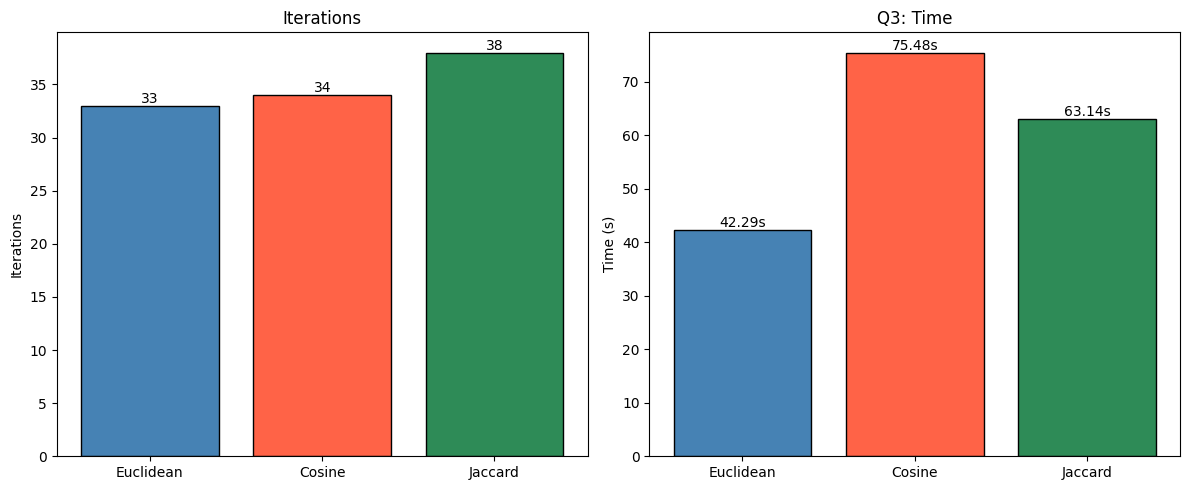

In [ ]:
iters = [euc_iters, cos_iters, jac_iters]
times = [euc_time, cos_time, jac_time]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

b1 = axes[0].bar(names, iters, color=colors, edgecolor='black')
axes[0].set_title("Iterations")
axes[0].set_ylabel("Iterations")
for bar, val in zip(b1, iters):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(val), ha='center', va='bottom')

b2 = axes[1].bar(names, times, color=colors, edgecolor='black')
axes[1].set_title("Q3: Time")
axes[1].set_ylabel("Time (s)")
for bar, val in zip(b2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}s", ha='center', va='bottom')

plt.tight_layout()
plt.savefig('q3_iters_time.png', dpi=150)
plt.show()

## Q4

In [ ]:
def run_kmeans_stop(X, K, dist_fn, stop_mode, max_iter=100, seed=42):
    np.random.seed(seed)
    n = X.shape[0]
    idx = np.random.choice(n, K, replace=False)
    centroids = X[idx].copy().astype(float)
    labels = np.zeros(n, dtype=int)
    sse_list = []

    for it in range(max_iter):
        new_labels = np.zeros(n, dtype=int)
        for i in range(n):
            dists = [dist_fn(X[i], centroids[k]) for k in range(K)]
            new_labels[i] = np.argmin(dists)

        sse = calc_sse(X, new_labels, centroids)
        sse_list.append(sse)

        if stop_mode == 'sse_increase' and it > 0:
            if sse > sse_list[-2]:
                break

        if stop_mode == 'no_change' and it > 0:
            if np.array_equal(new_labels, labels):
                break

        labels = new_labels

        for k in range(K):
            pts = X[labels == k]
            if len(pts) > 0:
                centroids[k] = np.mean(pts, axis=0)

    return sse_list[-1]

In [ ]:
euc_nc = run_kmeans_stop(X, K, euclidean_distance, 'no_change')
euc_si = run_kmeans_stop(X, K, euclidean_distance, 'sse_increase')
euc_mi = run_kmeans_stop(X, K, euclidean_distance, 'max_iter')

cos_nc = run_kmeans_stop(X, K, cosine_distance, 'no_change')
cos_si = run_kmeans_stop(X, K, cosine_distance, 'sse_increase')
cos_mi = run_kmeans_stop(X, K, cosine_distance, 'max_iter')

jac_nc = run_kmeans_stop(X, K, jaccard_distance, 'no_change')
jac_si = run_kmeans_stop(X, K, jaccard_distance, 'sse_increase')
jac_mi = run_kmeans_stop(X, K, jaccard_distance, 'max_iter')

In [ ]:
print("Q4 - SSE by stopping condition\n")
print(f"Euclidean | No Change: {euc_nc:.4f} | SSE Increase: {euc_si:.4f} | Max Iter: {euc_mi:.4f}")
print(f"Cosine    | No Change: {cos_nc:.4f} | SSE Increase: {cos_si:.4f} | Max Iter: {cos_mi:.4f}")
print(f"Jaccard   | No Change: {jac_nc:.4f} | SSE Increase: {jac_si:.4f} | Max Iter: {jac_mi:.4f}")

Q4 - SSE by stopping condition

Euclidean | No Change: 25414767689.9611 | SSE Increase: 25414767689.9611 | Max Iter: 25414767689.9611
Cosine    | No Change: 25489564392.2771 | SSE Increase: 25489044045.3560 | Max Iter: 25489564392.2771
Jaccard   | No Change: 25416346592.3901 | SSE Increase: 25415242340.2997 | Max Iter: 25416346592.3901


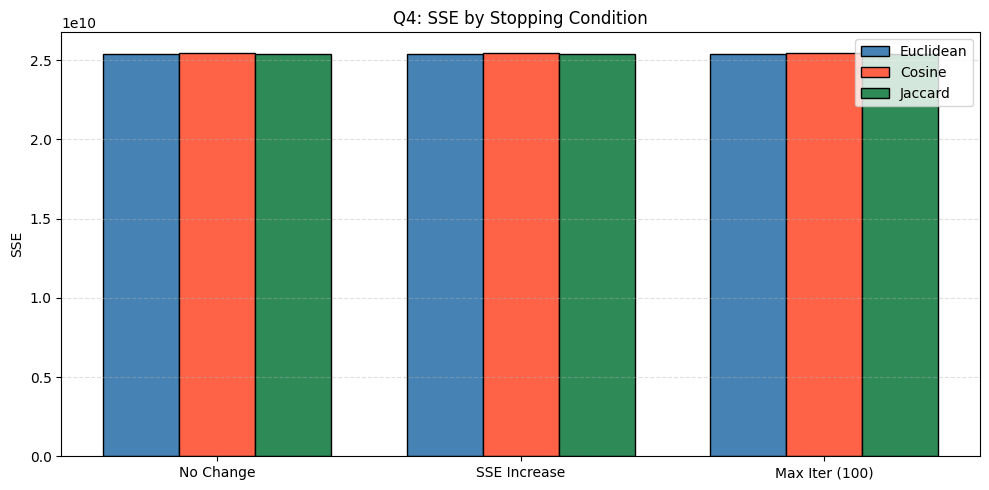

In [ ]:
euc_vals = [euc_nc, euc_si, euc_mi]
cos_vals = [cos_nc, cos_si, cos_mi]
jac_vals = [jac_nc, jac_si, jac_mi]

stop_labels = ['No Change', 'SSE Increase', 'Max Iter (100)']
x = np.arange(len(stop_labels))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, euc_vals, w, label='Euclidean', color='steelblue', edgecolor='black')
ax.bar(x, cos_vals, w, label='Cosine', color='tomato', edgecolor='black')
ax.bar(x + w, jac_vals, w, label='Jaccard', color='seagreen', edgecolor='black')
ax.set_title("SSE by Stopping Condition")
ax.set_ylabel("SSE")
ax.set_xticks(x)
ax.set_xticklabels(stop_labels)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('q4_sse_stop.png', dpi=150)
plt.show()

# Task 2

In [ ]:
!pip install numpy==1.26.4 scikit-surprise -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 9.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 66.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>

In [1]:
from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import cross_validate

In [5]:
ratings = pd.read_csv('ratings_small.csv')
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

## Q2c

In [6]:
pmf = SVD()
user_cf = KNNBasic(sim_options={'name': 'cosine', 'user_based': True})
item_cf = KNNBasic(sim_options={'name': 'cosine', 'user_based': False})

pmf_res = cross_validate(pmf, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
user_res = cross_validate(user_cf, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
item_res = cross_validate(item_cf, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)

pmf_rmse = np.mean(pmf_res['test_rmse'])
pmf_mae = np.mean(pmf_res['test_mae'])
user_rmse = np.mean(user_res['test_rmse'])
user_mae = np.mean(user_res['test_mae'])
item_rmse = np.mean(item_res['test_rmse'])
item_mae = np.mean(item_res['test_mae'])

print(f"PMF RMSE: {pmf_rmse:.4f}  MAE: {pmf_mae:.4f}")
print(f"User-based CF RMSE: {user_rmse:.4f}  MAE: {user_mae:.4f}")
print(f"Item-based CF RMSE: {item_rmse:.4f}  MAE: {item_mae:.4f}")

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
PMF RMSE: 0.8980  MAE: 0.6907
User-based CF RMSE: 0.9921  MAE: 0.7671
Item-based CF RMSE: 0.9964  MAE: 0.7755


## Q2d

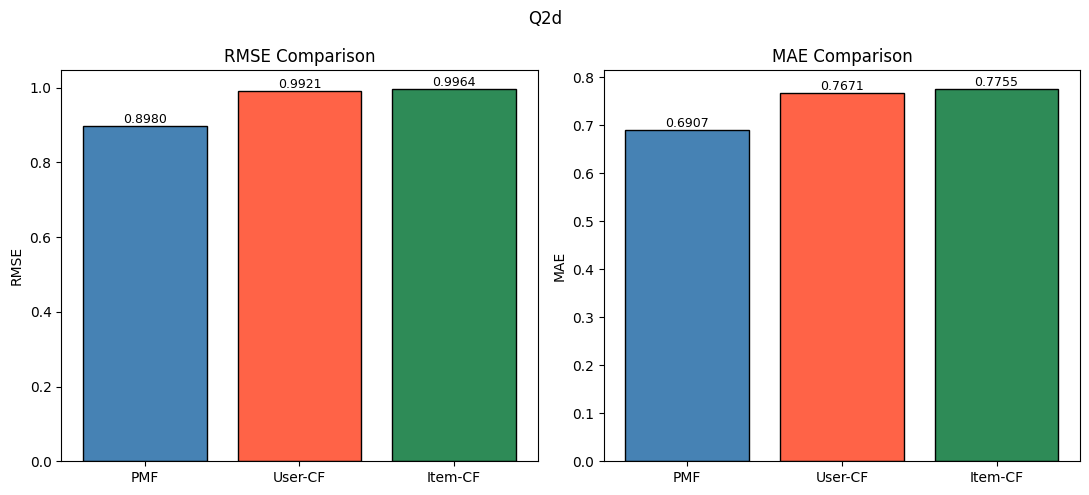

In [7]:
model_names = ['PMF', 'User-CF', 'Item-CF']
rmse_vals = [pmf_rmse, user_rmse, item_rmse]
mae_vals = [pmf_mae, user_mae, item_mae]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

b1 = axes[0].bar(model_names, rmse_vals, color=['steelblue', 'tomato', 'seagreen'], edgecolor='black')
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE")
for bar, val in zip(b1, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.4f}", ha='center', va='bottom', fontsize=9)

b2 = axes[1].bar(model_names, mae_vals, color=['steelblue', 'tomato', 'seagreen'], edgecolor='black')
axes[1].set_title("MAE Comparison")
axes[1].set_ylabel("MAE")
for bar, val in zip(b2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.4f}", ha='center', va='bottom', fontsize=9)

plt.suptitle("Q2d")
plt.tight_layout()
plt.savefig('q2d_model_comparison.png', dpi=150)
plt.show()

## Q2e

In [8]:
sim_metrics = ['cosine', 'msd', 'pearson']

u_rmse = []
u_mae = []
i_rmse = []
i_mae = []

for sim in sim_metrics:
    m1 = KNNBasic(sim_options={'name': sim, 'user_based': True})
    r1 = cross_validate(m1, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    u_rmse.append(np.mean(r1['test_rmse']))
    u_mae.append(np.mean(r1['test_mae']))

    m2 = KNNBasic(sim_options={'name': sim, 'user_based': False})
    r2 = cross_validate(m2, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    i_rmse.append(np.mean(r2['test_rmse']))
    i_mae.append(np.mean(r2['test_mae']))

for i, sim in enumerate(sim_metrics):
    print(f"{sim} -> User RMSE: {u_rmse[i]:.4f}, MAE: {u_mae[i]:.4f} | Item RMSE: {i_rmse[i]:.4f}, MAE: {i_mae[i]:.4f}")

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd sim

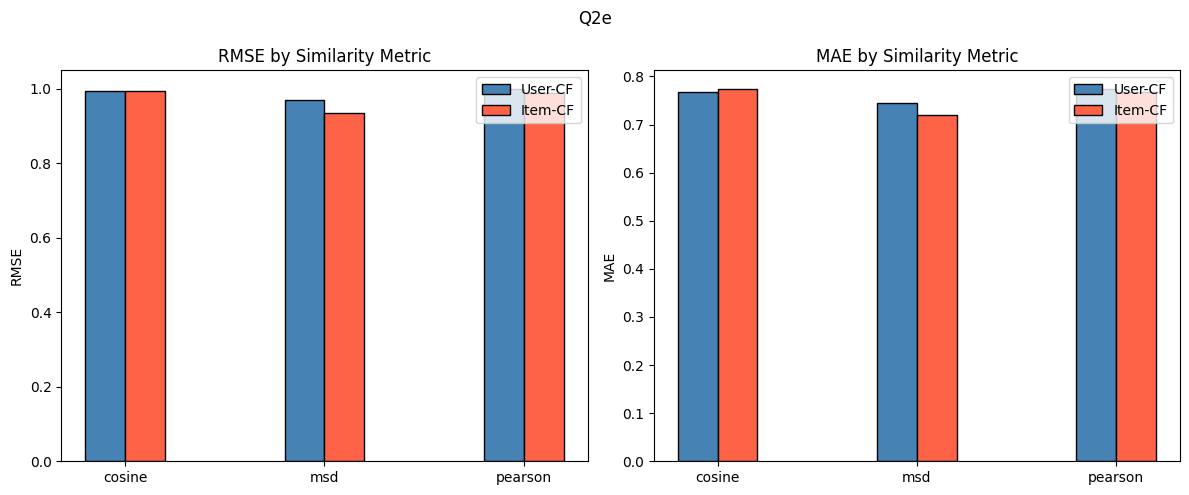

In [9]:
x = np.arange(len(sim_metrics))
w = 0.2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(x - w/2, u_rmse, w, label='User-CF', color='steelblue', edgecolor='black')
axes[0].bar(x + w/2, i_rmse, w, label='Item-CF', color='tomato', edgecolor='black')
axes[0].set_title("RMSE by Similarity Metric")
axes[0].set_ylabel("RMSE")
axes[0].set_xticks(x)
axes[0].set_xticklabels(sim_metrics)
axes[0].legend()

axes[1].bar(x - w/2, u_mae, w, label='User-CF', color='steelblue', edgecolor='black')
axes[1].bar(x + w/2, i_mae, w, label='Item-CF', color='tomato', edgecolor='black')
axes[1].set_title("MAE by Similarity Metric")
axes[1].set_ylabel("MAE")
axes[1].set_xticks(x)
axes[1].set_xticklabels(sim_metrics)
axes[1].legend()

plt.suptitle("Q2e")
plt.tight_layout()
plt.savefig('q2e_similarity.png', dpi=150)
plt.show()

## Q2f

In [10]:
k_vals = [5, 10, 20, 30, 40, 50]
u_rmse_k = []
i_rmse_k = []
u_mae_k = []
i_mae_k = []

for k in k_vals:
    m1 = KNNBasic(k=k, sim_options={'name': 'cosine', 'user_based': True})
    r1 = cross_validate(m1, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    u_rmse_k.append(np.mean(r1['test_rmse']))
    u_mae_k.append(np.mean(r1['test_mae']))

    m2 = KNNBasic(k=k, sim_options={'name': 'cosine', 'user_based': False})
    r2 = cross_validate(m2, data, measures=['RMSE', 'MAE'], cv=5, verbose=False)
    i_rmse_k.append(np.mean(r2['test_rmse']))
    i_mae_k.append(np.mean(r2['test_mae']))

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing th

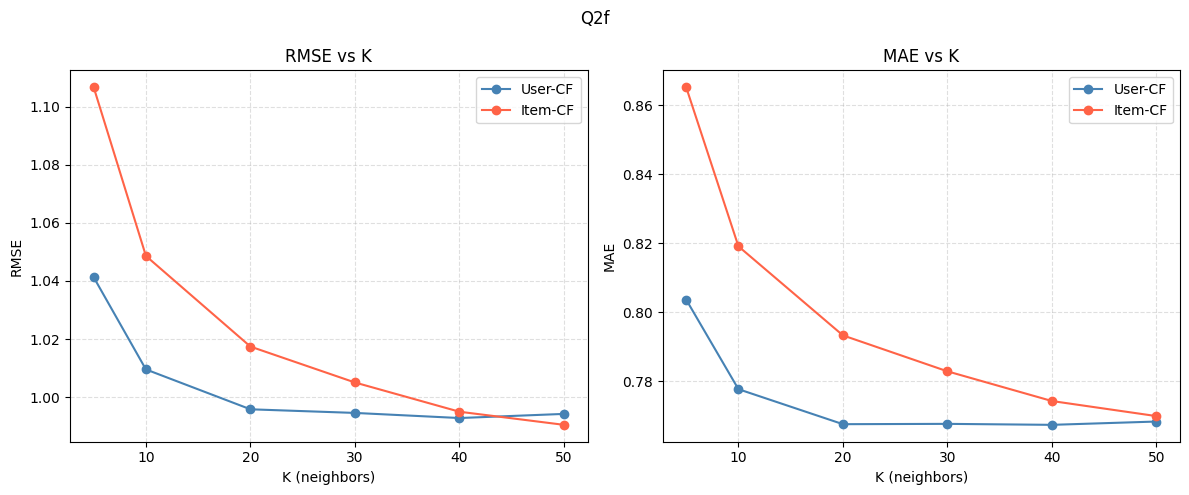

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(k_vals, u_rmse_k, marker='o', color='steelblue', label='User-CF')
axes[0].plot(k_vals, i_rmse_k, marker='o', color='tomato', label='Item-CF')
axes[0].set_title("RMSE vs K")
axes[0].set_xlabel("K (neighbors)")
axes[0].set_ylabel("RMSE")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(k_vals, u_mae_k, marker='o', color='steelblue', label='User-CF')
axes[1].plot(k_vals, i_mae_k, marker='o', color='tomato', label='Item-CF')
axes[1].set_title("MAE vs K")
axes[1].set_xlabel("K (neighbors)")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Q2f")
plt.tight_layout()
plt.savefig('q2f_neighbors.png', dpi=150)
plt.show()

## Q2g

In [12]:
best_u_idx = np.argmin(u_rmse_k)
best_i_idx = np.argmin(i_rmse_k)
best_u_k = k_vals[best_u_idx]
best_i_k = k_vals[best_i_idx]

print(f"Best K for User-CF: K={best_u_k}  (RMSE={u_rmse_k[best_u_idx]:.4f})")
print(f"Best K for Item-CF: K={best_i_k}  (RMSE={i_rmse_k[best_i_idx]:.4f})")

if best_u_k == best_i_k:
    print(f"\nSame best K for both: K={best_u_k}")
else:
    print(f"\nDifferent best K — User: {best_u_k}, Item: {best_i_k}")

Best K for User-CF: K=40  (RMSE=0.9928)
Best K for Item-CF: K=50  (RMSE=0.9904)

Different best K — User: 40, Item: 50
